In [1]:
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout
from sklearn.model_selection import train_test_split
from sklearn.utils import extmath
from module_utils import * 
sys.path.append('../utils')
from Structure3 import *
from data_collection import *
#######################     CONFIGURATIONS     ##########################
seed = 29
train = True
save = True

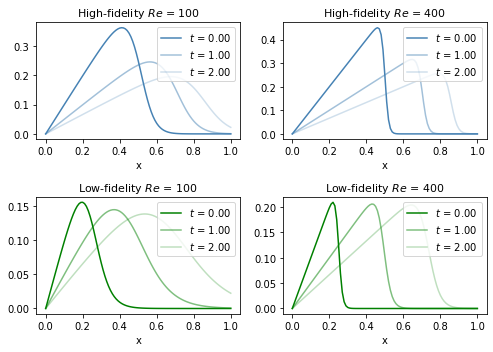

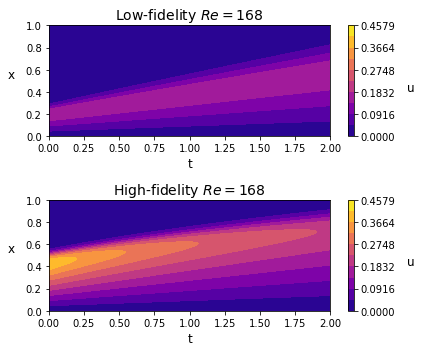

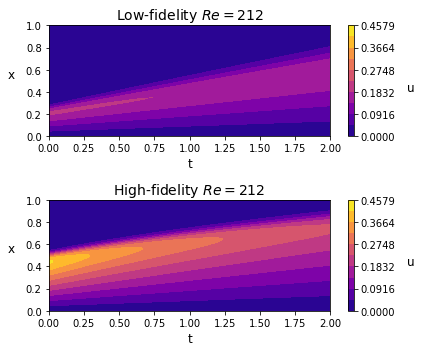

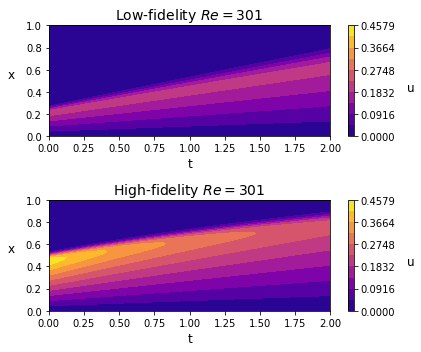

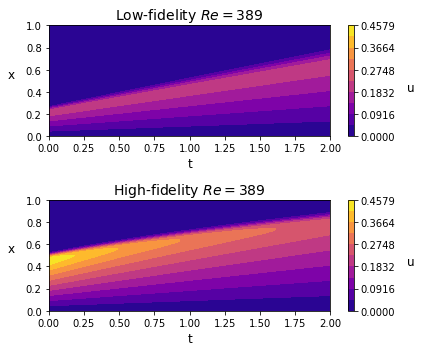

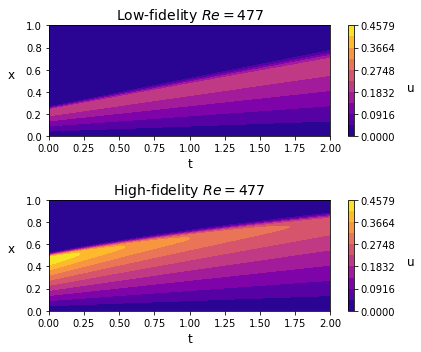

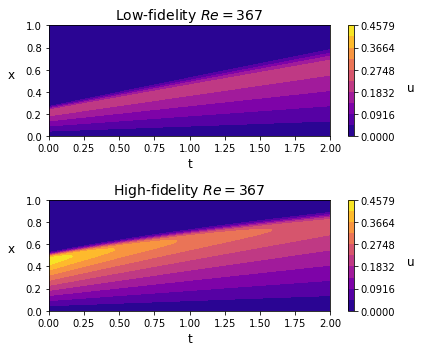

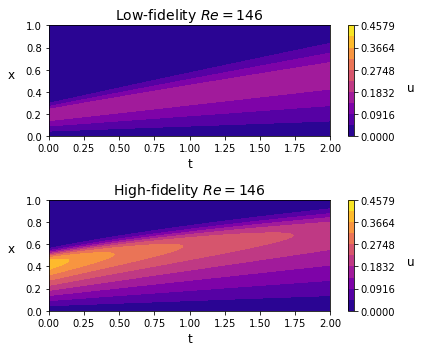

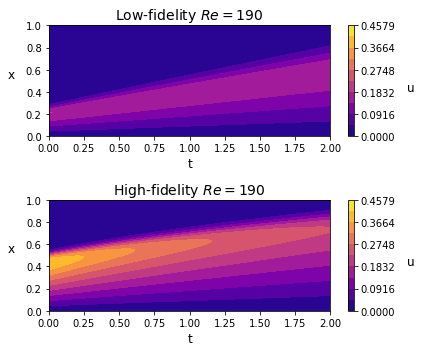

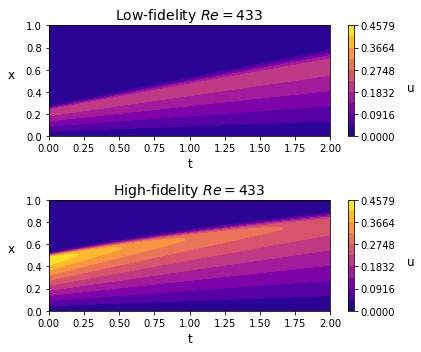

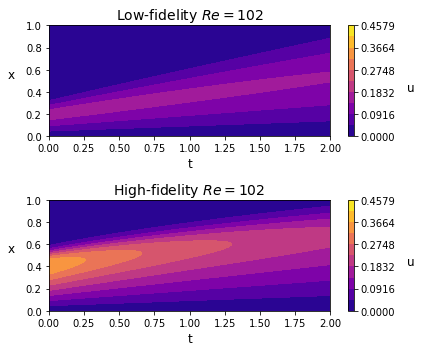

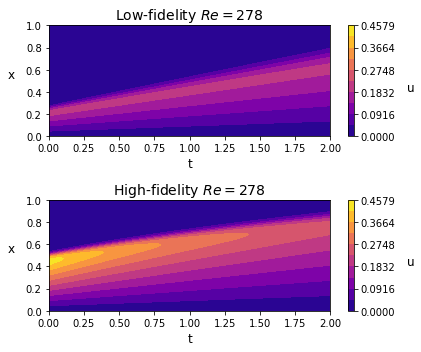

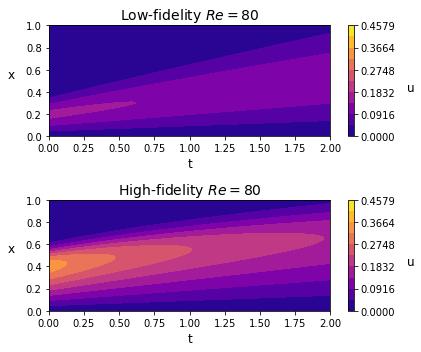

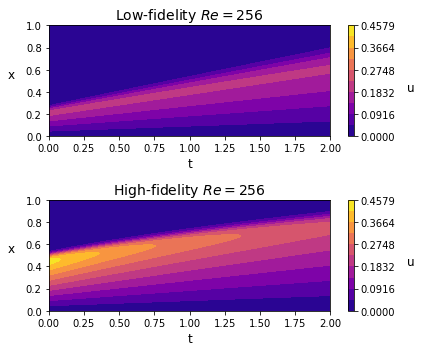

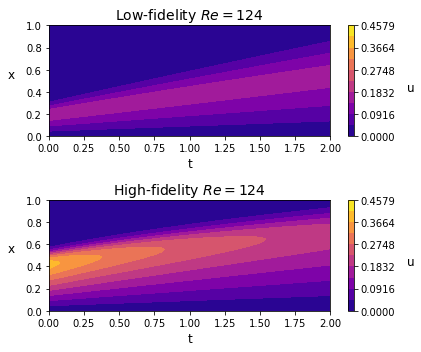

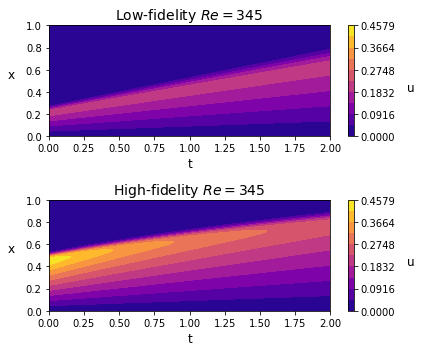

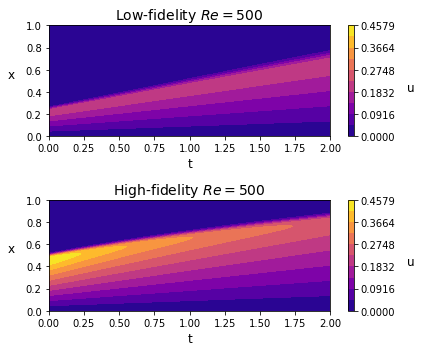

In [2]:
burger_eq = BurgerEquation(nh = 101, nt = 151, T= 2.0, L= 1.0, nre= 20, re_min = 80, re_max= 500, seed=seed)
burger_eq.generate_data()
burger_eq.plot_ground_truth_simulations()
burger_eq.plot_data()

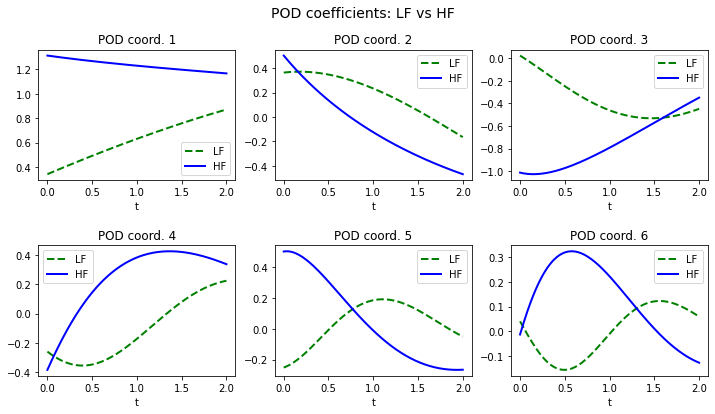

In [3]:
rom = ROM(burger_eq, n_POD=16)

input_train, output_train,input_test, output_test=rom.perform_POD()
rom.plot_POD_coefficients(ind_re=0)

In [12]:
input_train.shape

(20, 151, 18)

The function training took 151.755961 seconds.


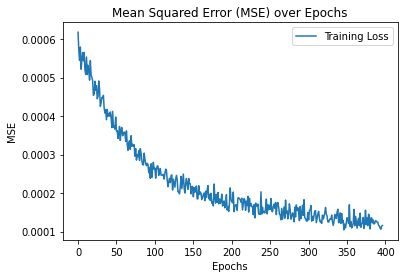

In [4]:

params_NN = { 'lay': 1,
             'nodes': 64,
             'lr':  1e-3,
             'opt': 'Adamax',
             'sequence_freq': 2,
             'sequence_length': 10,
             #'epochs':  500,
             'patience' : 50,
             'dropout' : 0.1}


definition_LSTM = {
    "network_type": "LSTM",
    "params": params_NN,
    "data_train": input_train,
    "output_train": output_train,
    "N": 500,
    "train": True,
    "do_HPO": False,
    "verbose": False
}


model = NetworkFactory.build_network(**definition_LSTM)

output_pred = model.prediction(input_test)
# Plot predicted POD coordinates
 # Re = 235

In [10]:
output_pred.shape

(4, 151, 16)

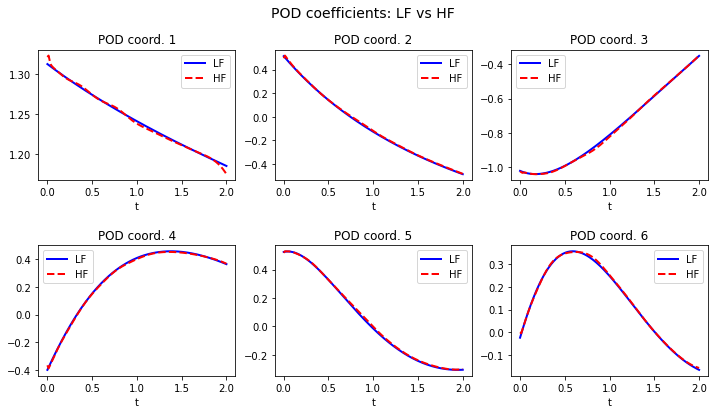

In [5]:
ind_re = [0]
rom.plot_POD_output(ind_re=ind_re, output_pred=output_pred)


In [14]:
rom.output_test.shape

(4, 151, 16)

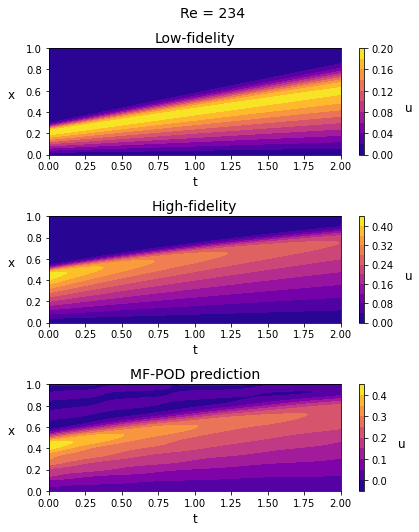

In [8]:
burger_eq.plot_comparison(output_pred, rom.get_basis(), ind_re)


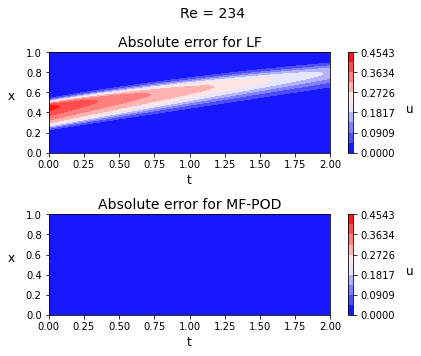

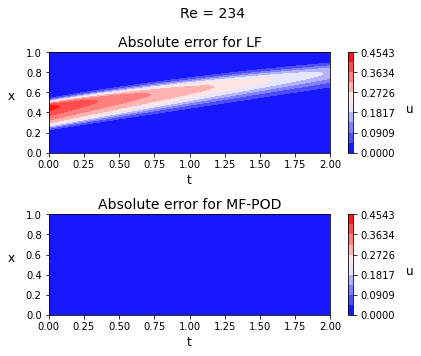

In [10]:
burger_eq.plot_error(output_pred, rom.get_basis(), ind_re)


In [ ]:
mean_prior =np.array([2.3,0.9,0.4,1.1])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])

sigma_noise = [0.25,0.5]
n_data = [50,30]
parameters =np.array([3.,1.2,1.35,1.825])
sigma = np.array([ 4.,2.])
rwmh_scaling = np.array([ 2.,0.5,1.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 300
burnin = 200
n_chains = 2
algo = "MH"


estimateMF, errorMF= run_simulation(x_HF, mean_prior, cov_prior, y_HF, sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model,algo)
